C:\Users\artge\AppData\Local\Temp\ipykernel_16796\356223335.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m = int(mat_contents['m'])
C:\Users\artge\AppData\Local\Temp\ipykernel_16796\356223335.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n = int(mat_contents['n'])


Aby zachować > 15% informacji, potrzebujemy r = 1 twarzy własnych (eigenfaces).


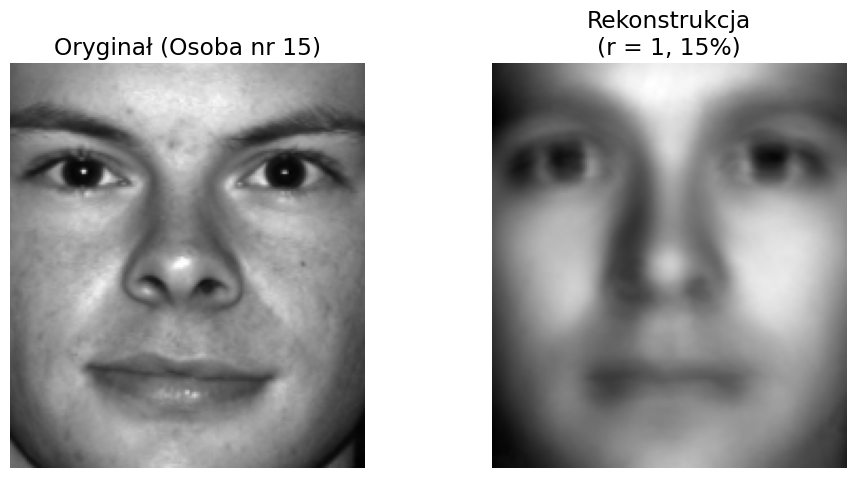

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.io

plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams.update({'font.size': 14})

mat_contents = scipy.io.loadmat('allFaces.mat')
faces = mat_contents['faces']
m = int(mat_contents['m'])
n = int(mat_contents['n'])
nfaces = np.ndarray.flatten(mat_contents['nfaces'])

trainingFaces = faces[:, :np.sum(nfaces[:36])]
avgFace = np.mean(trainingFaces, axis=1) # rozmiar n*m na 1

X = trainingFaces - np.tile(avgFace, (trainingFaces.shape[1], 1)).T

U, S, VT = np.linalg.svd(X, full_matrices=False)

k_percent = 15
person_num = 15

variance_explained = np.cumsum(S**2) / np.sum(S**2)

r = np.argmax(variance_explained > (k_percent / 100.0)) + 1
print(f"Aby zachować > {k_percent}% informacji, potrzebujemy r = {r} twarzy własnych (eigenfaces).")

start_idx = np.sum(nfaces[:(person_num-1)]) 
x_test = faces[:, start_idx]

x_test_centered = x_test - avgFace

U_r = U[:, :r]

x_reconstructed_centered = U_r @ U_r.T @ x_test_centered

x_reconstructed = x_reconstructed_centered + avgFace

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(np.reshape(x_test, (m, n)).T, cmap='gray')
plt.title(f'Oryginał (Osoba nr {person_num})')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(np.reshape(x_reconstructed, (m, n)).T, cmap='gray')
plt.title(f'Rekonstrukcja\n(r = {r}, {k_percent}%)')
plt.axis('off')

plt.tight_layout()
plt.show()